# ANALYSIS OF MENTAL HEALTH IN THE TECH INDUSTRY

### INTRODUCTION

<small>

**OBJECTIVE**: 


In recent years, awareness of the connection between workplace environment and mental health has grown significantly. The tech industry, in particular, has been highlighted as a field where employees face a heightened risk of burnout and other mental health challenges. The goal is to derive data-driven recommendations for tech companies on how to create a more supportive work environment and enhance the well-being of their employees.

**DATA**: 

This project aims to analyse survey data from Open Source Mental Illness (OSMI) to understand the attitudes toward mental health in the tech industry and the frequency of mental health disorders.

**STRUCTURE**:  

- Importing Packages
- Data Loading
- Data Extraction 
- Data Cleaning 
- Exploratory Data Analysis (EDA)
- Conclusions
- Improvements 

**LIMITATIONS**: 

This analysis has several limitations that may affect the interpretation of results. These include sampling bias, incomplete data across survey years, and potential constraints in generalizing findings.

1. Gender Bias: The dataset contains more male than female respondents, suggesting gender imbalance. Given that the tech industry is historically male-dominated, this may reflect industry trends. However, if the survey distribution did not intentionally reach a diverse gender population, this could skew the findings. 

2. Geographic Bias: A higher concentration of respondents from California, Washington, and New York suggests that the data is skewed toward regions with large tech hubs (e.g., Silicon Valley, Seattle, and NYC). 

3. Temporal Bias (Declining Response Rates Over Time): Respondent count has dropped over the years since 2014, meaning that the sample sizes across survey years are inconsistent.  

4. Incomplete Data Across Survey Years: Some questions do not span all years, meaning that certain insights are only available for specific periods.  
</small>


### IMPORTING PACKAGES

In [68]:
import importlib
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mental_health_ import data_cleaning_vis
from mental_health_ import data_extraction

importlib.reload(data_cleaning_vis)
importlib.reload(data_extraction)

from mental_health_.data_cleaning_vis import *
from mental_health_.data_extraction import *

### DATA LOADING

In [69]:
conn = get_db_connection()

### DATA EXTRACTION


Before performing EDA, we need to extract the relevant data from our SQL database and clean it to ensure consistency. The final DataFrame from this step will be used for EDA in the next section.



#### What tables exist in the database?

In [70]:
df_tables = get_table_names(conn)
print(df_tables)


       name
0    Answer
1  Question
2    Survey


#### What are the column names in each table?

In [71]:
get_table_schema(conn)

Columns in Answer: ['AnswerText', 'SurveyID', 'UserID', 'QuestionID']
Columns in Question: ['questiontext', 'questionid']
Columns in Survey: ['SurveyID', 'Description']


#### What is the total sample size?

In [72]:
df_sample_size = get_total_respondents(conn)
print(df_sample_size)

   Respondents
0         4218


#### What is the sample size per year?

In [73]:
df_respondents_per_year = get_respondents_per_year(conn)
print(df_respondents_per_year)


   Year  Respondents
0  2014         1260
1  2016         1433
2  2017          756
3  2018          417
4  2019          352


#### How consistently are questions present across survey years and which questions will be retained for final analysis? 

In [74]:
df_full_questions, df_partial_questions, total_years = analyse_question_availability(conn)

print(f"Questions available in ONLY SOME years: {df_partial_questions.shape[0]}")
print(f"Questions available in ALL survey years below: {df_full_questions.shape[0]}")

display(df_full_questions.set_index('QuestionID').drop('Year_Count', axis=1))


Questions available in ONLY SOME years: 93
Questions available in ALL survey years below: 12


,Questions
QuestionID,
1,What is your age?
2,What is your gender?
3,What country do you live in?
4,"If you live in the United States, which state ..."
5,Are you self-employed?
6,Do you have a family history of mental illness?
7,Have you ever sought treatment for a mental he...
8,How many employees does your company or organi...
9,Is your employer primarily a tech company/orga...


<small>

#### Explanation 

For the purposes of this analysis, I intend to capture all the sociodemographic features of the respondents raised consistently over the years as well as the other questions covered in all years apart from questionid 6 and 7. The reason I selected these questions are because they are the most relevant to my research goal of providing recommendations to tech companies on how to enhance the well-being of their employees. The data quality is also complete for these questisons which will give my analysis more confidence. As well as these questions, I have selected more questions from the list which are also relevant to my analysis goal. To summarise, the 15 questions that I will focus on are: 

1. questionid 1: What is your age?
2. questionid 2: What is your gender? 
3. questionid 3: What country do you live in?
4. questionid 4: If you live in the United States, which state or territory do you live in? 
5. questionid 5: Are you self-employed?
6. questionid 8: How many employees does your company or organization have?
7. questionid 9: Is your employer primarily a tech company/organization? 
8. questionid 10: Does your employer provide mental health benefits as part of healthcare coverage?
9. questionsid 11: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer? 
10. questionid 12: Would you bring up a mental health issue with a potential employer in an interview?
11. questionid 33: Do you currently have a mental health disorder?
12. questionid 56: Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your workplace?
13. questionid 91: Do you feel that your employer takes mental health as seriously as physical health? 
14. questionid 115: If yes, what conditions have you been diagnosed with? 
15. questionid 116: If maybe, what conditions do you believe you have?  

Below, I will now explore some of the questions in more detail to better tailor the analysis. 

<small>

#### What is the age distribution of the respondents by year? 

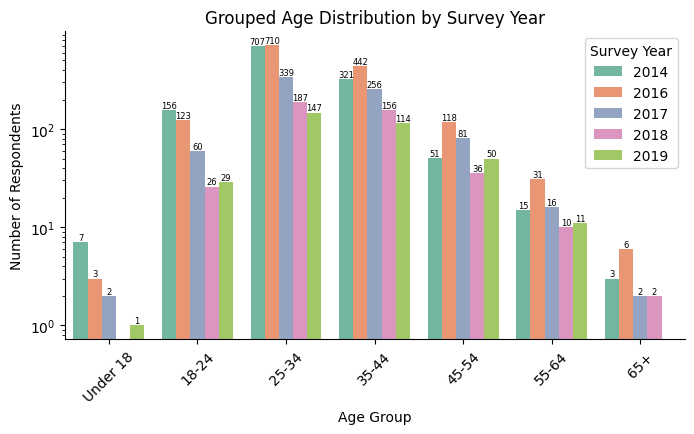

In [75]:
df_age_grouped = get_age_distribution(conn)
plot_age_distribution(df_age_grouped)

##### Explanation: 
Based on the distribution of respondents across different age groups, it is evident that the number of participants under 18 and over 65 is significantly lower than those in the 18-65 range. Also, since the goal of this analysis focuses on assisting employees of tech companies, it is reasonable to exclude those under 18, as they are typically not part of the full-time workforce. Similarly, many individuals over 65 are retired, meaning their inclusion may not align with the primary focus of the study. For these reasosns, I will limit the age range to 18-65 in the final dataframe. 


#### What is the overall gender distribution of the respondents?

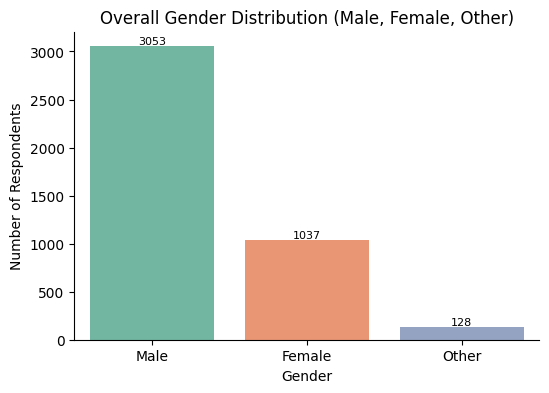

In [76]:
df_gender_grouped = get_gender_distribution(conn)
plot_gender_distribution(df_gender_grouped)


#### Explanation 

Male respondents dominate the sample – 3053 males vs. 1037 females and 128 "Other" respondents, reflecting the gender gap in tech.
Non-binary and other gender identities are a small minority with just 128 respondents. All gender categories will be maintained in the dataframe to ensure inclusivity and allow for meaningful analysis of gender-based differences in mental health trends.

#### In which countries do the respondents live?

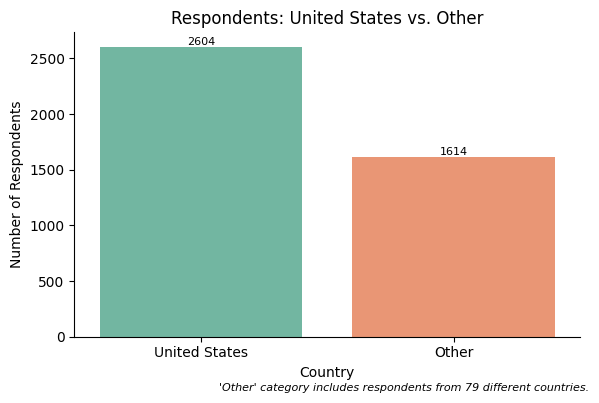

In [77]:
df_country_grouped, num_other_countries = get_country_distribution(conn)
plot_country_distribution(df_country_grouped, num_other_countries)

#### Explanation 

US respondents dominate the dataset (2,604 respondents) and "Other" includes 1,614 respondents from 79 countries, making analysis difficult. For consistency, I will limit the analysis to US respondents to avoid fragmentation across multiple regions.  

#### Where do US respondents live by state or territory?

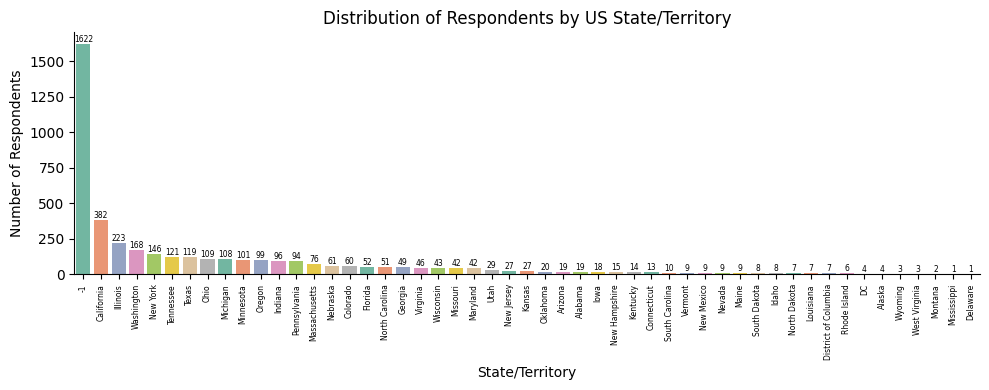

In [78]:
df_state = get_state_distribution(conn)
plot_state_distribution(df_state)

#### Explanation 

A significant portion of responses (1,622) have missing state information (-1). These likely represent participants who either skipped the question or were non-U.S. respondents. California has the highest number of valid responses with 382 respondents, making it the most represented state. Other states, like Illinois (223), Washington (168), and New York (146), also have a notable presence. I will keep all this data in my final dataframe, apart from the missing values (-1), of which the majority will be removed naturally as I have decided to remove 'Other' Countries.


#### Are the respondents self-employed or employees of a company?

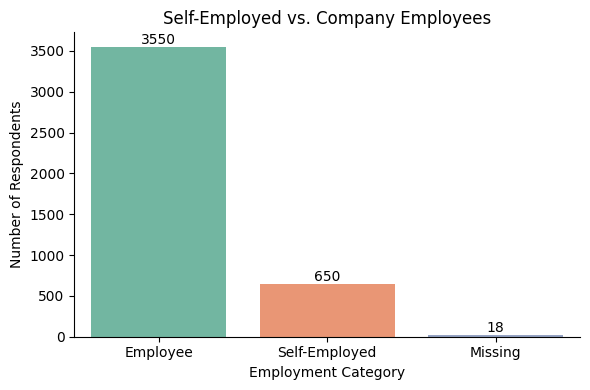

In [79]:
employment_counts = get_employment_distribution(conn)
plot_employment_distribution(employment_counts)


#### Explanation 

From the distribution, employees make up the majority of respondents (3,550 employees vs. 650 self-employed individuals). Since the focus of this analysis is on employees working within companies, I will remove self-employed respondents (650) as their work environment differs from company-employed individuals. I will also remove missing values for sake of completeness. 


#### Are the employers tech companies/organisations?

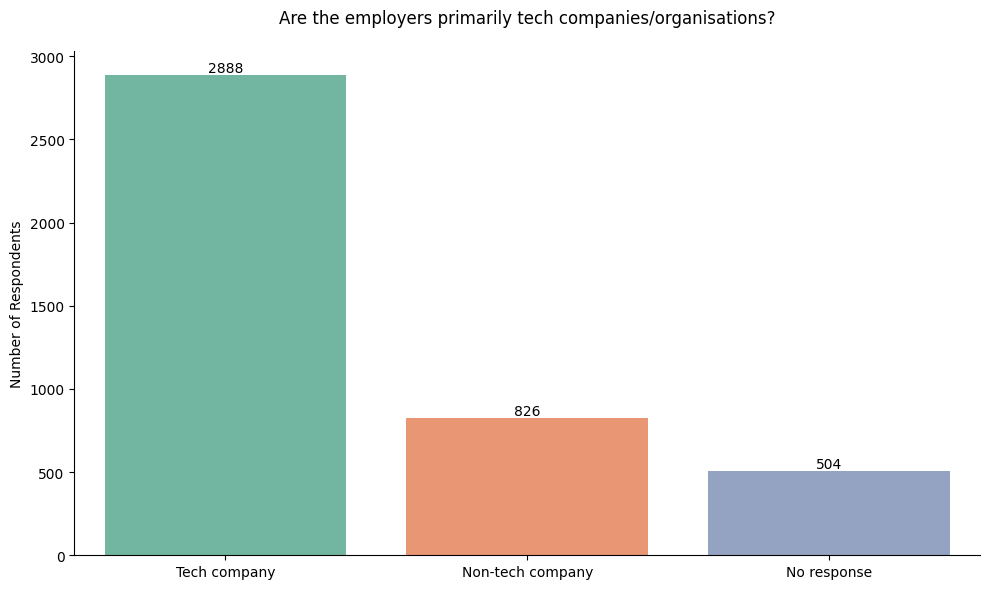

In [80]:
df_tech_company = get_company_type_distribution(conn)
plot_company_type_distribution(df_tech_company)

<small>

**Explanation**

The survey responses show the following distribution:
- **Tech Companies (1)**: Majority of respondents (predominant workplace type)
- **Non-Tech Companies (0)**: Smaller but significant portion
- **No Response (-1)**: Minimal non-responses, indicating good data quality

**Data Cleaning Decision:**  
For the purpose of analysing mental health specifically in the tech industry, the subsequent analysis will:
- ✓ Retain responses from tech companies
- ✗ Remove non-tech company responses
- ✗ Remove no-responses

**Rationale:**  
This filtering ensures our analysis remains focused on the tech industry environment, allowing for more targeted insights and recommendations for tech company workplace practices.
</small>

#### Extracted Dataframe 

In [81]:
df_extracted = get_full_survey_data(conn)
display(df_extracted.head())

,UserID,SurveyID,age,gender,country,us_state,employment,mental_health_disorder,mental_health_benefits,unsupportive_response,company_size,anonymity_protected,tech_company,interview_mental_health,diagnosed_conditions,suspected_conditions,employer_priorities
0,1,2014,37,Female,United States,Illinois,-1,None,Yes,None,6-25,Yes,1,No,None,None,Yes
1,2,2014,44,Male,United States,Indiana,-1,None,Don't know,None,More than 1000,Don't know,0,No,None,None,Don't know
2,3,2014,32,Male,Canada,-1,-1,None,No,None,6-25,Don't know,1,Yes,None,None,No
3,4,2014,31,Male,United Kingdom,-1,-1,None,No,None,26-100,No,1,Maybe,None,None,No
4,5,2014,31,Male,United States,Texas,-1,None,Yes,None,100-500,Don't know,1,Yes,None,None,Don't know


<small> 

#### Explanation 

We have successfully extracted the relevant data from the database into our initial dataframe. Before proceeding with exploratory data analysis (EDA), we need to clean and filter the data according to our analysis requirements:

1. Age Range: Filter respondents between 18-65 years old
2. Geographic Focus: Standardise country names and focus on U.S. respondents
3. Gender Categories: Consolidate gender responses into standardised categories
4. Employment Status: Focus analysis on employees, excluding self-employed individuals
5. Tech Company: remove all non-tech company responses. 

The next step will be implementing these data cleaning procedures to create our final analysis-ready dataset.

<small>


### DATA CLEANING

In [82]:
df_extracted = get_full_survey_data(conn)
df_filtered = clean_and_filter_data(df_extracted)
display(df_filtered.head())

,userid,surveyid,age,gender,country,us_state,employment,mental_health_disorder,mental_health_benefits,unsupportive_response,company_size,anonymity_protected,tech_company,interview_mental_health,diagnosed_conditions,suspected_conditions,employer_priorities
0,21,2014,29,Male,United States,New York,Employee,None,Yes,None,100-500,No,Tech Company,No,None,None,No
1,23,2014,46,Male,United States,Massachusetts,Employee,None,Yes,None,26-100,Don't know,Tech Company,No,None,None,No
2,25,2014,33,Male,United States,California,Employee,None,Yes,None,26-100,Yes,Tech Company,No,None,None,Don't know
3,27,2014,33,Male,United States,Tennessee,Employee,None,Don't know,None,1-5,Don't know,Tech Company,No,None,None,Don't know
4,28,2014,35,Female,United States,California,Employee,None,Yes,None,6-25,Don't know,Tech Company,Maybe,None,None,Yes


### EDA

This EDA will be structured as follows: 

1. Dataset overview 
2. Sociodemographic analysis 
3. Mental health prevalence 
4. Workplace environment 
5. Benefits and support 
6. Geographic and company size variations 

### 1. Dataset overview

#### How many observations (rows) and features (columns) are there in the dataset?

In [83]:
# Get number of rows and columns using shape
num_rows, num_columns = df_filtered.shape
print(f"Number of observations (rows): {num_rows}")
print(f"Number of features (columns): {num_columns}")

Number of observations (rows): 1765
Number of features (columns): 17


#### What features are categorical and numerical in the dataset? 

<small>

Since this dataset has been filtered to include only US based employees working in tech companies, certain questions are no longer relevant for exploratory data analysis (EDA). Specifically, the following questions have been excluded:  

- **QuestionID 3:** *What country do you live in?*  
- **QuestionID 5:** *Are you self-employed?*  
- **QuestionID 9:** *Is your employer primarily a tech company/organization?*  

Below is a breakdown of the remaining features, categorised into categorical and numerical variables:  

Categorical Features
- **QuestionID 2:** *What is your gender?*  
- **QuestionID 4:** *If you live in the United States, which state or territory do you live in?*  
- **QuestionID 10:** *Does your employer provide mental health benefits as part of healthcare coverage?*
- **QuestionID 11:** *Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?*  
- **QuestionID 12:** *Would you bring up a mental health issue with a potential employer in an interview?*  
- **QuestionID 33:** *Do you currently have a mental health disorder?*  
- **QuestionID 56:** *Have you observed or experienced an unsupportive or poorly handled response to a mental health issue in your workplace?*  
- **QuestionID 91:** *Do you feel that your employer takes mental health as seriously as physical health?*  
- **QuestionID 115:** *What conditions have you been diagnosed with?*  
- **QuestionID 116:** *What conditions do you believe you have?*  

Numerical Features
- **QuestionID 1:** *What is your age?*  
- **QuestionID 8:** *How many employees does your company or organization have?*  

<small>


### 2. Demographic Analysis

##### What is the sociodemographic distribution of tech company employees living in the US?

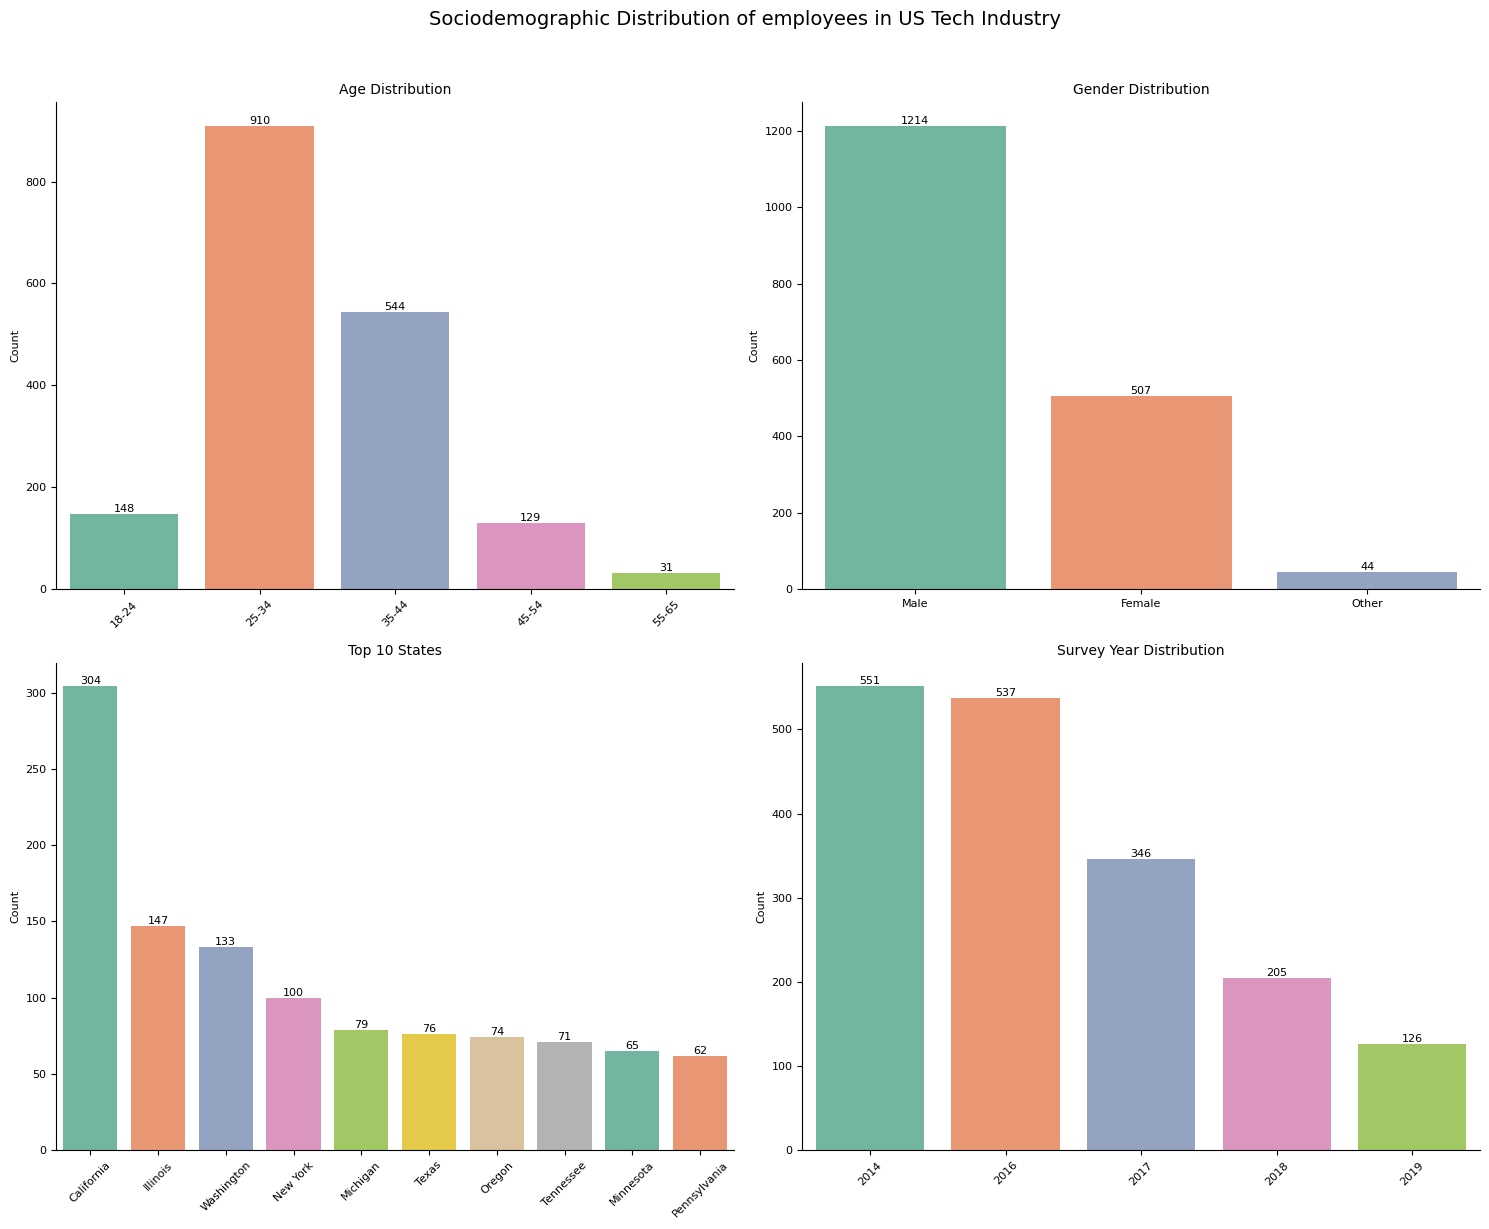

,Age
Min,18
1st Quartile,28
Median,32
Mean,34
3rd Quartile,38
Max,63
n,1765
SD,8


In [84]:

summary_df = plot_demographic_summary(df_filtered)
display(summary_df)

<small>

#### Explanation 

Age Distribution 
- The majority of respondents fall within the 25–34 age group, followed by the 35–44 age group. There are significantly fewer respondents in the younger (18–24) and older (45+) age brackets. 

Gender Distribution
- The survey responses indicate a strong male majority in the tech industry, with over 1,200 male respondents. Female representation** is significantly lower at 507 respondents, highlighting a gender disparity. A small number of respondents identify as "Other", indicating that gender diversity beyond male and female remains limited in the dataset.  

Top 10 States Representation
- California has the highest number of respondents, reinforcing its status as a key hub for tech employment. Illinois and Washington follow, suggesting strong tech presence beyond Silicon Valley.  

Survey Year Distribution
- The highest number of responses were recorded in 2014 and 2016, indicating strong participation in those years. There was a noticeable decline in responses from 2017 onwards, suggesting a potential decrease in survey reach or participation.  

<small>


##### What is the distribution of tech company sizes?

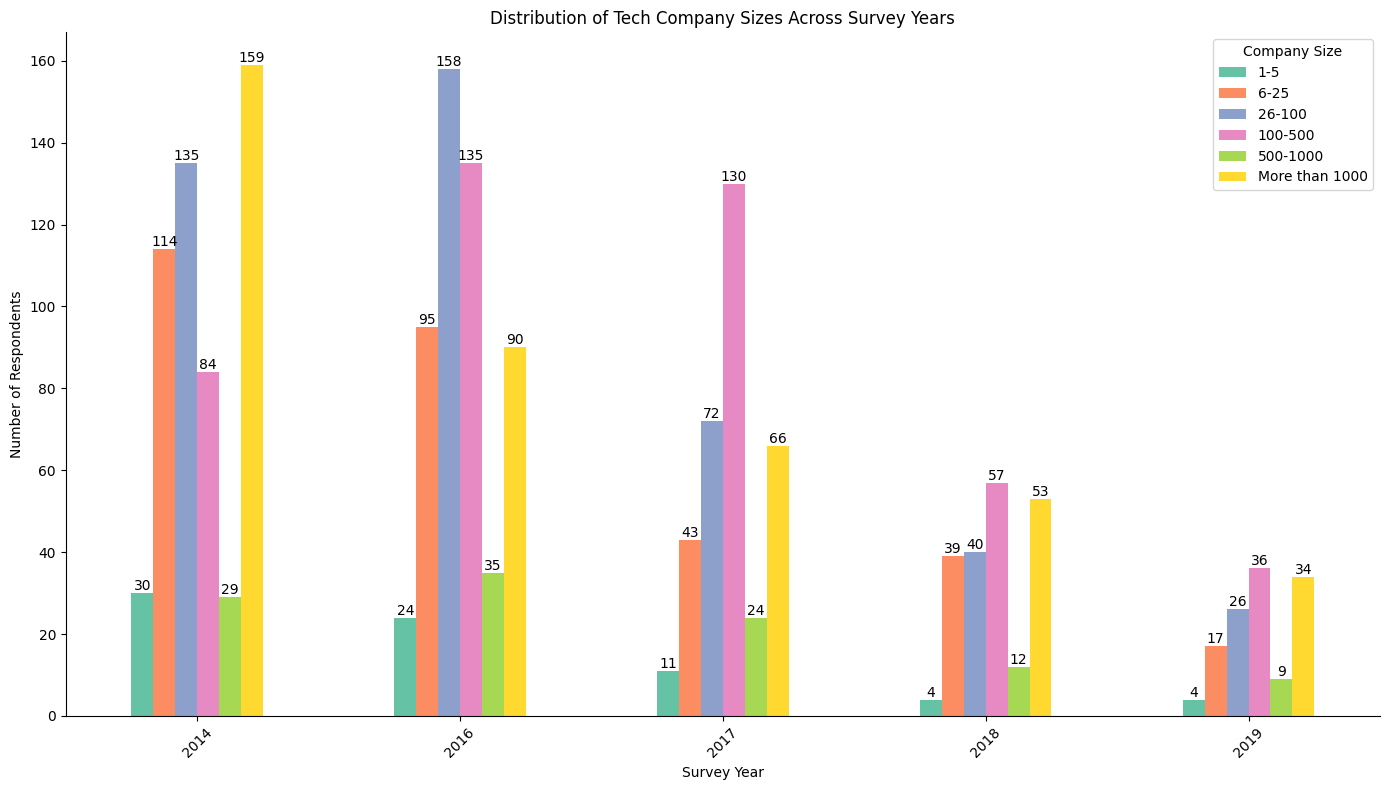

In [85]:
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']

df_filtered['company_size'] = pd.Categorical(df_filtered['company_size'], categories=size_order, ordered=True)
grouped = df_filtered.groupby(['surveyid', 'company_size']).size().unstack(fill_value=0)

ax = grouped.plot(kind='bar', figsize=(14, 8), color=sns.color_palette('Set2', n_colors=len(size_order)))

plt.title('Distribution of Tech Company Sizes Across Survey Years')
plt.xlabel('Survey Year')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.legend(title='Company Size')

for container in ax.containers:
    ax.bar_label(container, label_type='edge')
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


<small>

##### Explanation 
- **Large companies** were consistently well-represented throughout the survey.  
- **Mid-sized companies** saw an increase in representation in later years.  
- **Smallest companies (1–5 employees)** consistently had the **fewest respondents** across all years. 
<small>

##### How do age and gender distributions vary across different company sizes?

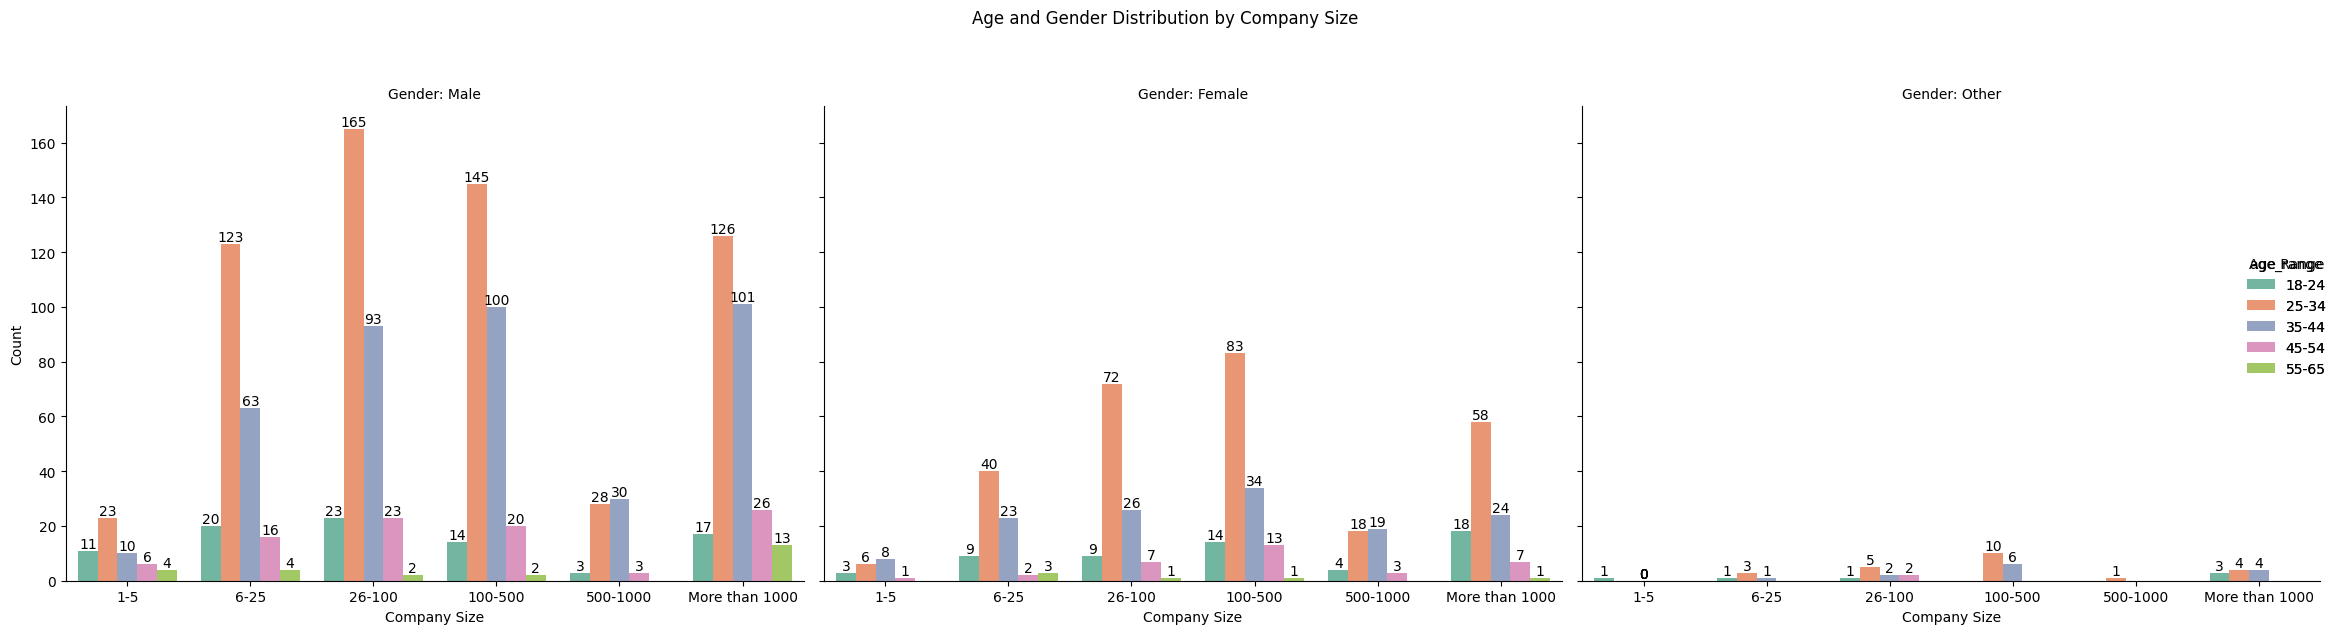

In [86]:

df_filtered['age'] = pd.to_numeric(df_filtered['age'], errors='coerce')

age_bins = [18, 25, 35, 45, 55, 66]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

df_filtered['age_range'] = pd.cut(df_filtered['age'], bins=age_bins, labels=age_labels, right=False)

g = sns.catplot(
    data=df_filtered,
    x='company_size',
    hue='age_range',
    col='gender',
    kind='count',
    palette='Set2',
    height=6,
    aspect=1.2
)

for ax in g.axes.flat:
    for p in ax.patches:
        ax.text(
            p.get_x() + p.get_width() / 2, 
            p.get_height(), 
            int(p.get_height()), 
            ha='center', 
            va='bottom'
        )


g.set_axis_labels('Company Size', 'Count')
g.set_titles('Gender: {col_name}')
g.add_legend(title='Age Range')
g.figure.suptitle('Age and Gender Distribution by Company Size', y=1.05)

plt.tight_layout()
plt.show()

<small>

##### **Explanation** 
- Males represent the majority across all company sizes.  
- The 25-34 age group is the most prevalent, followed by 35-44, particularly in mid-to-large companies.  
- Older employees (55-65) are notably underrepresented, indicating potential barriers to hiring or retention.  

These trends suggest that the primary workforce demographic consists of males aged 25 to 44.

<small>

##### Are certain demographics (gender, age) more likely to report mental health disorders?

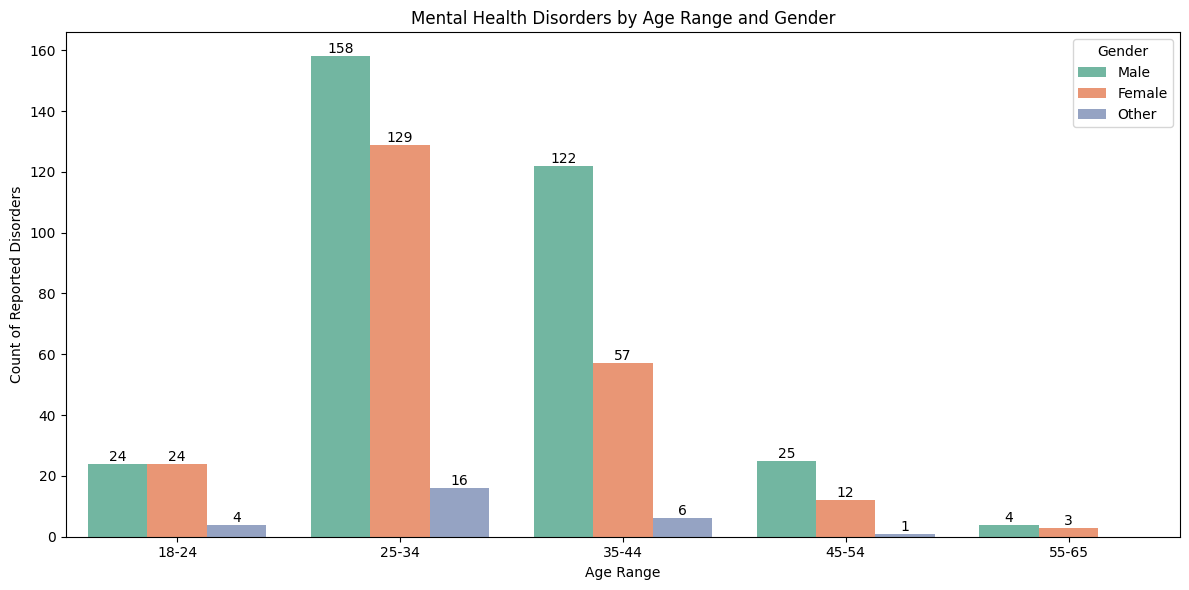

In [87]:
df_filtered['age'] = pd.to_numeric(df_filtered['age'], errors='coerce')

age_bins = [18, 25, 35, 45, 55, 66]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

df_filtered['age_range'] = pd.cut(df_filtered['age'], bins=age_bins, labels=age_labels, right=False)

# Filter data for those reporting mental health disorders
disorder_data = df_filtered[df_filtered['mental_health_disorder'] == 'Yes']

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='age_range', hue='gender', data=disorder_data, palette='Set2')

for p in ax.patches:
    if p.get_height() > 0:  # Only annotate bars with a positive height
        ax.text(
            p.get_x() + p.get_width() / 2, 
            p.get_height(), 
            int(p.get_height()), 
            ha='center', 
            va='bottom'
    )

plt.title('Mental Health Disorders by Age Range and Gender')
plt.xlabel('Age Range')
plt.ylabel('Count of Reported Disorders')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

<small>

##### **Explanation** 
- The 25-34 age group reports the highest number of mental health disorders**, with males showing the highest count, followed by females.  
- The 35-44 age group follows, with a significant drop in reported disorders compared to 25-34.  

These findings highlight that younger employees, particularly males, report more mental health disorders, emphasising the need for targeted workplace mental health support.

<small>

### 3. Mental Health Prevalence

##### What is the prevalence of the most common diagnosed and self-reported mental health conditions among employees?

In [88]:
invalid_entries = ['-1', 'etc)']
diagnosed_counts = df_filtered['diagnosed_conditions'].str.split(', ').explode()
diagnosed_counts = diagnosed_counts[~diagnosed_counts.isin(invalid_entries)].value_counts()

suspected_counts = df_filtered['suspected_conditions'].str.split(', ').explode()
suspected_counts = suspected_counts[~suspected_counts.isin(invalid_entries)].value_counts()

print("Diagnosed Conditions Counts:")
print(diagnosed_counts.head(3))

print("\nSuspected Conditions Counts:")
print(suspected_counts.head(3))

Diagnosed Conditions Counts:
diagnosed_conditions
Mood Disorder (Depression         134
Bipolar Disorder                  134
Post-traumatic Stress Disorder     23
Name: count, dtype: int64

Suspected Conditions Counts:
suspected_conditions
Mood Disorder (Depression        50
Bipolar Disorder                 50
Anxiety Disorder (Generalized    17
Name: count, dtype: int64


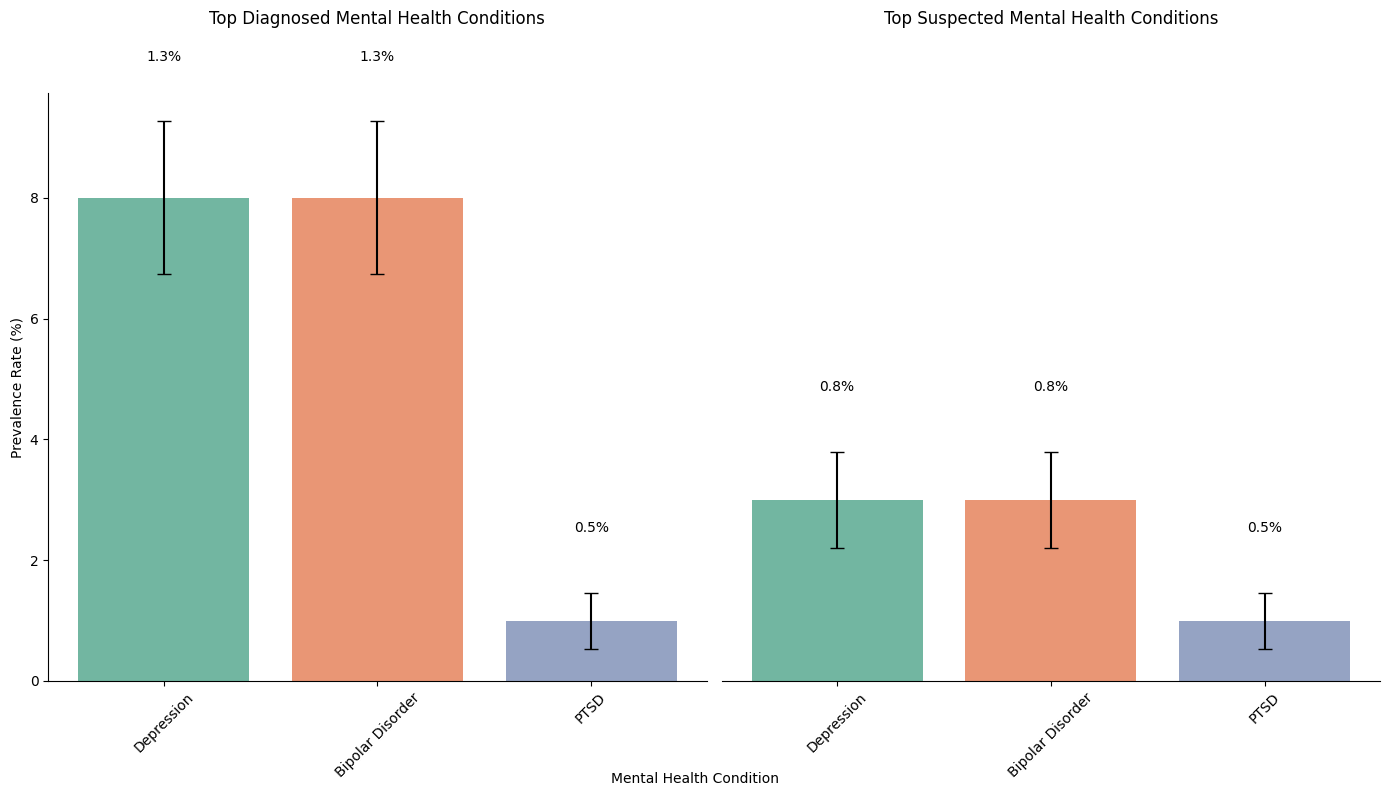

In [89]:

invalid_entries = ['-1', 'etc)']

diagnosed_counts = df_filtered['diagnosed_conditions'].str.split(', ').explode()
diagnosed_counts = diagnosed_counts[~diagnosed_counts.isin(invalid_entries)].value_counts()


suspected_counts = df_filtered['suspected_conditions'].str.split(', ').explode()
suspected_counts = suspected_counts[~suspected_counts.isin(invalid_entries)].value_counts()

diagnosed_categories = {'Depression': 0, 'Bipolar Disorder': 0, 'PTSD': 0}
suspected_categories = {'Depression': 0, 'Bipolar Disorder': 0, 'Anxiety Disorder': 0}


for condition, count in diagnosed_counts.items():
    if 'Depression' in condition:
        diagnosed_categories['Depression'] += count
    elif 'Bipolar' in condition:
        diagnosed_categories['Bipolar Disorder'] += count
    elif 'Post-traumatic Stress' in condition:
        diagnosed_categories['PTSD'] += count

for condition, count in suspected_counts.items():
    if 'Depression' in condition:
        suspected_categories['Depression'] += count
    elif 'Bipolar' in condition:
        suspected_categories['Bipolar Disorder'] += count
    elif 'Anxiety' in condition:
        suspected_categories['Anxiety Disorder'] += count


diagnosed_df = pd.DataFrame.from_dict(diagnosed_categories, orient='index', columns=['Prevalence'])
suspected_df = pd.DataFrame.from_dict(suspected_categories, orient='index', columns=['Prevalence'])

# Calculate prevalence rates
sample_size = len(df_filtered)
diagnosed_df['Prevalence'] = (diagnosed_df['Prevalence'] / sample_size * 100).round()
suspected_df['Prevalence'] = (suspected_df['Prevalence'] / sample_size * 100).round()

# Calculate confidence intervals
diagnosed_df['CI'] = 1.96 * np.sqrt((diagnosed_df['Prevalence'] * (100 - diagnosed_df['Prevalence'])) / sample_size)
suspected_df['CI'] = 1.96 * np.sqrt((suspected_df['Prevalence'] * (100 - suspected_df['Prevalence'])) / sample_size)

# Plot side by side with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# Diagnosed plot
bars = sns.barplot(x=diagnosed_df.index, y='Prevalence', data=diagnosed_df, palette='Set2', ax=axes[0], ci=None)
axes[0].set_title('Top Diagnosed Mental Health Conditions', pad=50)
axes[0].set_xlabel('')
axes[0].set_ylabel('Prevalence Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
for i, (prevalence, ci) in enumerate(zip(diagnosed_df['Prevalence'], diagnosed_df['CI'])):
    axes[0].errorbar(i, prevalence, yerr=ci, fmt='none', c='black', capsize=5)
    axes[0].text(i, prevalence + ci + 1, f'{ci:.1f}%', ha='center')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Suspected plot
bars = sns.barplot(x=suspected_df.index, y='Prevalence', data=suspected_df, palette='Set2', ax=axes[1], ci=None)
axes[1].set_title('Top Suspected Mental Health Conditions', pad=50)
axes[1].set_ylabel('Prevalence Rate (%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
for i, (prevalence, ci) in enumerate(zip(suspected_df['Prevalence'], suspected_df['CI'])):
    axes[1].errorbar(i, prevalence, yerr=ci, fmt='none', c='black', capsize=5)
    axes[1].text(i, prevalence + ci + 1, f'{ci:.1f}%', ha='center')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(left=False)

fig.text(0.5, 0.02, 'Mental Health Condition', ha='center', va='center')

plt.tight_layout()
plt.show()

<small>


##### **Interpretation**

Top Diagnosed Mental Health Conditions
- Depression and Bipolar Disorder: Both conditions have a prevalence rate of 8%. The confidence interval (CI) for each is 1.3%. This means the true prevalence is likely between 6.7% and 9.3% with 95% confidence, indicating some variability in the estimates. 
- PTSD: Has a lower prevalence rate of 1%, with a CI of 0.5%. This suggests less variability in the data for PTSD compared to the other conditions.

Top Suspected Mental Health Conditions
- Depression and Bipolar Disorder: Both have a suspected prevalence rate of 3%, with a CI of 0.8%. This suggests moderate confidence in the estimated prevalence.
- Anxiety Disorder: Shows a prevalence rate of 1%, with a CI of 0.5%, indicating a narrower range of uncertainty.

<small>





#### How has the prevalence of diagnosed and suspected mental health conditions changed over the years?

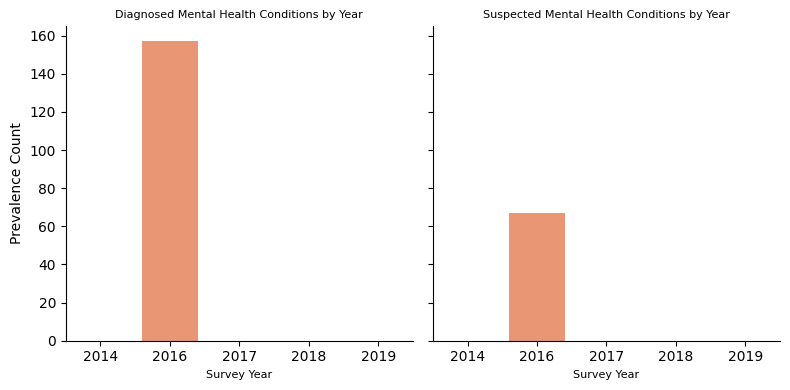

In [90]:
df_filtered['age'] = pd.to_numeric(df_filtered['age'], errors='coerce')

invalid_entries = ['-1', 'etc)']

diagnosed_counts = df_filtered['diagnosed_conditions'].str.split(', ').explode()
diagnosed_counts = diagnosed_counts[~diagnosed_counts.isin(invalid_entries)]

suspected_counts = df_filtered['suspected_conditions'].str.split(', ').explode()
suspected_counts = suspected_counts[~suspected_counts.isin(invalid_entries)]

diagnosed_categories = {'Depression': 0, 'Bipolar Disorder': 0, 'PTSD': 0}
suspected_categories = {'Depression': 0, 'Bipolar Disorder': 0, 'Anxiety Disorder': 0}

for condition, count in diagnosed_counts.value_counts().items():
    if 'Depression' in condition:
        diagnosed_categories['Depression'] += count
    elif 'Bipolar' in condition:
        diagnosed_categories['Bipolar Disorder'] += count
    elif 'Post-traumatic Stress' in condition:
        diagnosed_categories['PTSD'] += count

for condition, count in suspected_counts.value_counts().items():
    if 'Depression' in condition:
        suspected_categories['Depression'] += count
    elif 'Bipolar' in condition:
        suspected_categories['Bipolar Disorder'] += count
    elif 'Anxiety' in condition:
        suspected_categories['Anxiety Disorder'] += count

diagnosed_df = pd.DataFrame.from_dict(diagnosed_categories, orient='index', columns=['Prevalence'])
suspected_df = pd.DataFrame.from_dict(suspected_categories, orient='index', columns=['Prevalence'])

diagnosed_yearly = df_filtered.groupby('surveyid')['diagnosed_conditions'].apply(lambda x: x.str.contains('Depression|Bipolar|Post-traumatic Stress').sum()).reset_index(name='Prevalence')
suspected_yearly = df_filtered.groupby('surveyid')['suspected_conditions'].apply(lambda x: x.str.contains('Depression|Bipolar|Anxiety').sum()).reset_index(name='Prevalence')

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)


sns.barplot(x='surveyid', y='Prevalence', data=diagnosed_yearly, ax=axes[0], palette='Set2')
axes[0].set_title('Diagnosed Mental Health Conditions by Year', fontsize=8)
axes[0].set_xlabel('Survey Year', fontsize=8)
axes[0].set_ylabel('Prevalence Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

sns.barplot(x='surveyid', y='Prevalence', data=suspected_yearly, ax=axes[1], palette='Set2')
axes[1].set_title('Suspected Mental Health Conditions by Year', fontsize=8)
axes[1].set_xlabel('Survey Year', fontsize=8)
axes[1].set_ylabel('Prevalence Count')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

<small>

##### **Explanation**
- There are only results for diagnosed and suspected mental health conditions in 2016, with no reported data for other years in this dataset.  
- The absence of data for other years suggests *either missing responses or reduced participation in later years.  

<small>


### 4. Workplace Environment

##### What is the distribution of employee anonymity protection for using company mental health resources? 

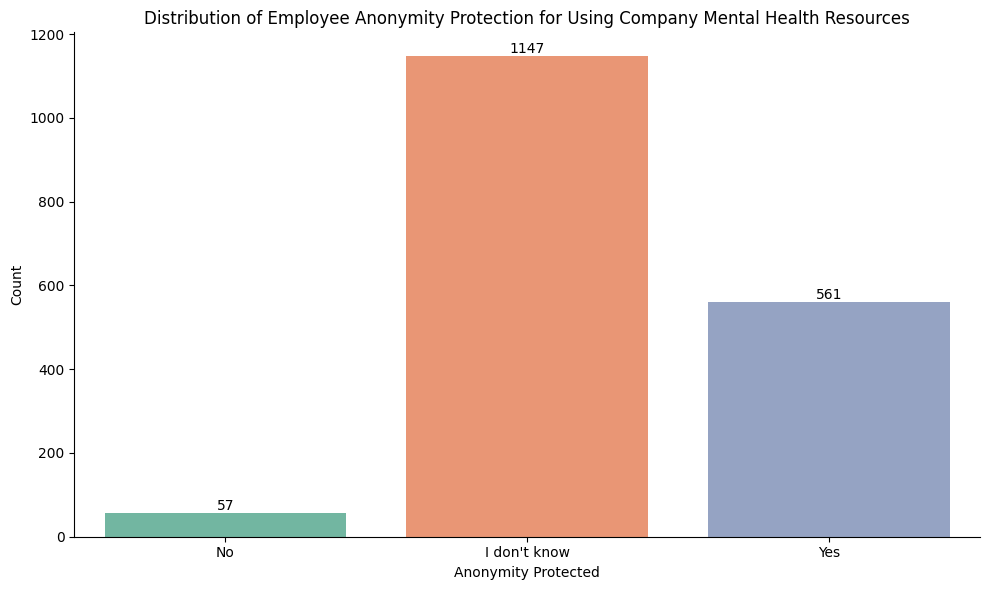

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_filtered is already defined and contains the necessary data

# Combine "Don't know" and "I don't know" into a single category
df_filtered['anonymity_protected'] = df_filtered['anonymity_protected'].replace(
    {"Don't know": "I don't know", "I don't know": "I don't know"}
)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='anonymity_protected', data=df_filtered, palette='Set2')

# Add numbers on top of each bar
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2, 
        p.get_height(), 
        int(p.get_height()), 
        ha='center', 
        va='bottom'
    )
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customization
plt.title('Distribution of Employee Anonymity Protection for Using Company Mental Health Resources')
plt.xlabel('Anonymity Protected')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

<small>

##### **Explanation** 

- The largest proportion of respondents (1,147) indicated that they do not know whether their anonymity is protected when using mental health resources.
- A smaller portion (561 respondents) confirmed that their anonymity is protected, while only 57 respondents explicitly stated that their anonymity is not protected.

- **Suggestions for Employers:**  
  - **Increase transparency** about mental health policies to reduce uncertainty.  
  - **Clearly communicate** employee rights regarding anonymity to build trust in mental health support systems.  
 <small>






##### What is the distribution of employees willing to discuss mental health issues in an interview?

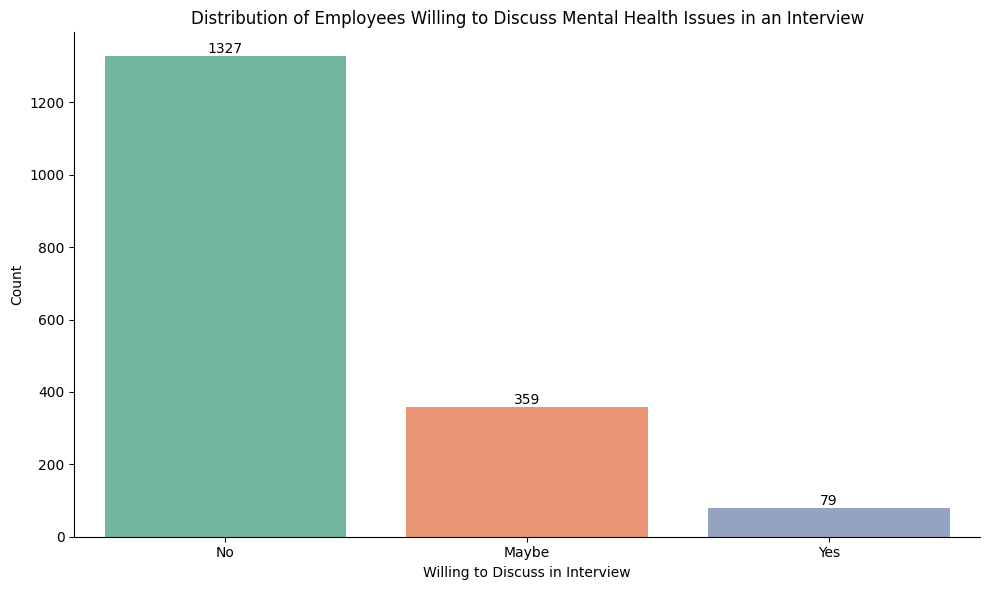

In [92]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='interview_mental_health', data=df_filtered, palette='Set2')

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2, 
        p.get_height(), 
        int(p.get_height()), 
        ha='center', 
        va='bottom'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Distribution of Employees Willing to Discuss Mental Health Issues in an Interview')
plt.xlabel('Willing to Discuss in Interview')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

<small>

##### **Explanation** 

- The vast majority of employees (1,327 respondents) are not willing to discuss mental health issues during a job interview.  
- A smaller group (**359 respondents**) indicated they might discuss their mental health, suggesting hesitation or concern about potential stigma.  
- Only 79 respondents expressed willingness to openly discuss their mental health in an interview.  

#### **Implications for Employers:**
- **Foster an Inclusive Workplace:** Address the stigma surrounding mental health discussions to create a culture of openness and support.  
- **Encourage Transparency in Hiring:** Employers should clarify whether mental health accommodations exist and ensure that discussing mental health does not impact hiring decisions.  

<small>






##### Are employees more likely to experience an unsupportive workplace response if their employer does not prioritise mental health?

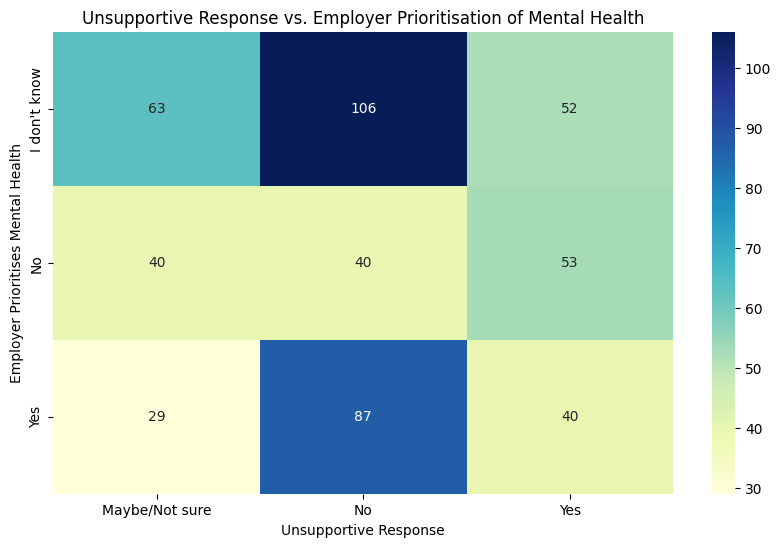

In [103]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

df_filtered = df_filtered[(df_filtered['unsupportive_response'] != '-1') & (df_filtered['unsupportive_response'] != 'Unknown')]


df_filtered['unsupportive_response'] = df_filtered['unsupportive_response'].replace(
    {'Yes, I experienced': 'Yes', 'Yes, I observed': 'Yes'}
)

df_filtered = df_filtered[df_filtered['employer_priorities'] != 'Unknown']


df_filtered['employer_priorities'] = df_filtered['employer_priorities'].replace(
    {"I don't know": "I don't know", "Don't know": "I don't know"}
)

contingency_table = pd.crosstab(df_filtered['employer_priorities'], df_filtered['unsupportive_response'])

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Unsupportive Response vs. Employer Prioritisation of Mental Health')
plt.xlabel('Unsupportive Response')
plt.ylabel('Employer Prioritises Mental Health')
plt.show()

<small>

##### **Explanation**

  - Employees who haven’t observed a poorly handled mental health issue are more likely to believe their employer prioritises mental health (87 employees).  
  - 106 employees who don’t know if their employer prioritises mental health have also not observed an unsupportive response.   
  - 53 employees in workplaces that do not prioritise mental health have seen an unsupportive response.  
  - 40 employees in companies that prioritise mental health still reported an unsupportive response, highlighting a gap between policy and practice.  

##### **Recommendations for Employers:**
- Enhance **transparency** around mental health policies.  
- Bridge the gap between policy and employee perception through better communication.  

<small>


### 5. Benefits and Support

##### Do employees with access to mental health benefits report fewer mental health disorders?

Pearson correlation: 0.1603159068413461


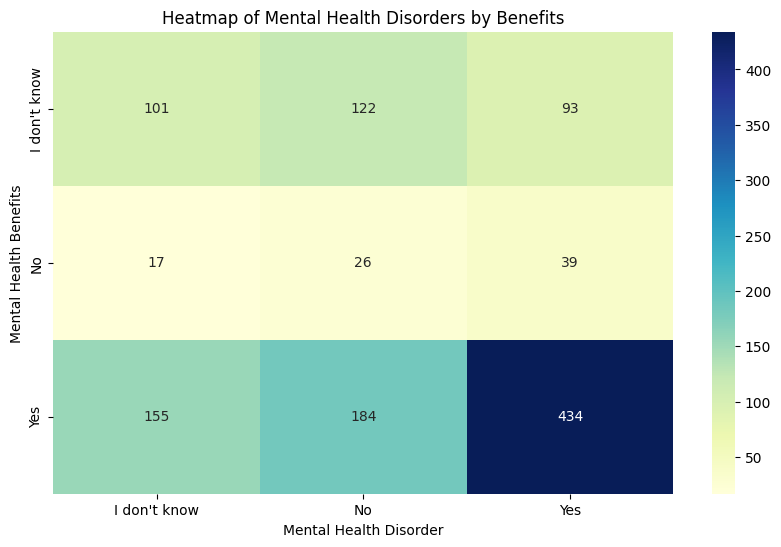

In [105]:

df_filtered['mental_health_benefits'] = df_filtered['mental_health_benefits'].str.strip()

df_filtered = df_filtered[~df_filtered['mental_health_benefits'].str.contains('Not eligible for coverage', na=False)]

df_filtered['mental_health_disorder'] = df_filtered['mental_health_disorder'].replace(
    {'Possibly': "I don't know", 'Maybe': "I don't know", "Don't Know": "I don't know"}
)
benefits_mapping = {'Yes': 1, 'No': 0, "I don't know": 0.5}
disorder_mapping = {'Yes': 1, 'No': 0, "I don't know": 0.5}
df_filtered['mental_health_benefits_num'] = df_filtered['mental_health_benefits'].map(benefits_mapping)
df_filtered['mental_health_disorder_num'] = df_filtered['mental_health_disorder'].map(disorder_mapping)

correlation = df_filtered[['mental_health_benefits_num', 'mental_health_disorder_num']].corr().iloc[0, 1]

print("Pearson correlation:", correlation)
contingency_table = pd.crosstab(df_filtered['mental_health_benefits'], df_filtered['mental_health_disorder'])

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Heatmap of Mental Health Disorders by Benefits')
plt.xlabel('Mental Health Disorder')
plt.ylabel('Mental Health Benefits')

plt.show()

<small>

##### **Explanation** 
- The Pearson correlation coefficient of 0.16 indicates a weak positive correlation between mental health benefits and reporting disorders. This suggests a slight tendency for increased reporting of disorders with benefits, but the relationship is not strong. 




<small>

##### Does company size influence whether employees feel their employer takes mental health seriously?

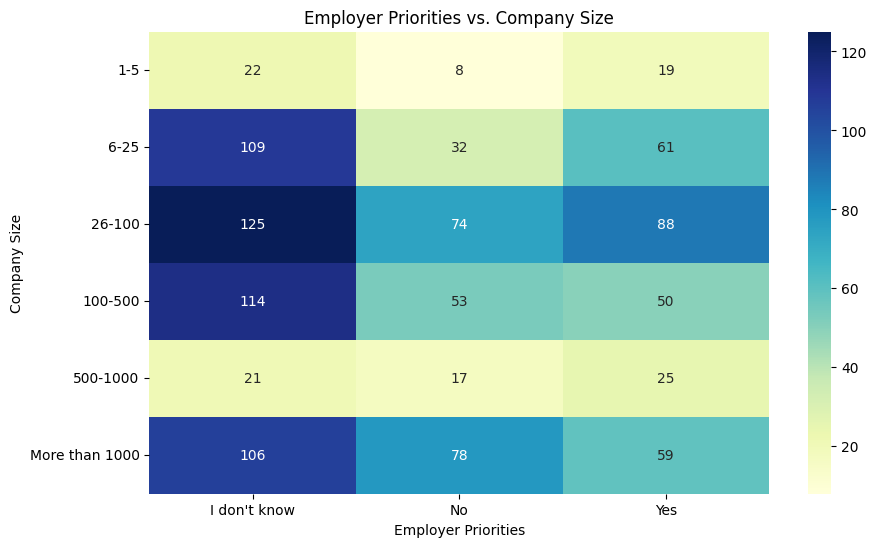

In [106]:
df_filtered['employer_priorities'] = df_filtered['employer_priorities'].replace(
    {"Don't know": "I don't know"}
)

contingency_table = pd.crosstab(df_filtered['company_size'], df_filtered['employer_priorities'])

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Employer Priorities vs. Company Size')
plt.xlabel('Employer Priorities')
plt.ylabel('Company Size')
plt.show()

<small>

##### **Explanation** 

- Larger companies (100+ employees) have high "I don’t know" responses, indicating potential communication gaps.  
- Mid-sized companies (26-100 employees) show the highest "Yes" responses, suggesting clearer employer priority recognition.  
- Small companies (1-5 employees) have low responses across all categories, implying less formal employer priority structures.  

**Recommendations** 

- Overall, increase communication flows on priotising mental health initiatives to reduce uncertainty. 


<small>

### 6. Geographic, Company Size Variations and Other 

##### Do mental health disorder rates vary significantly by state?

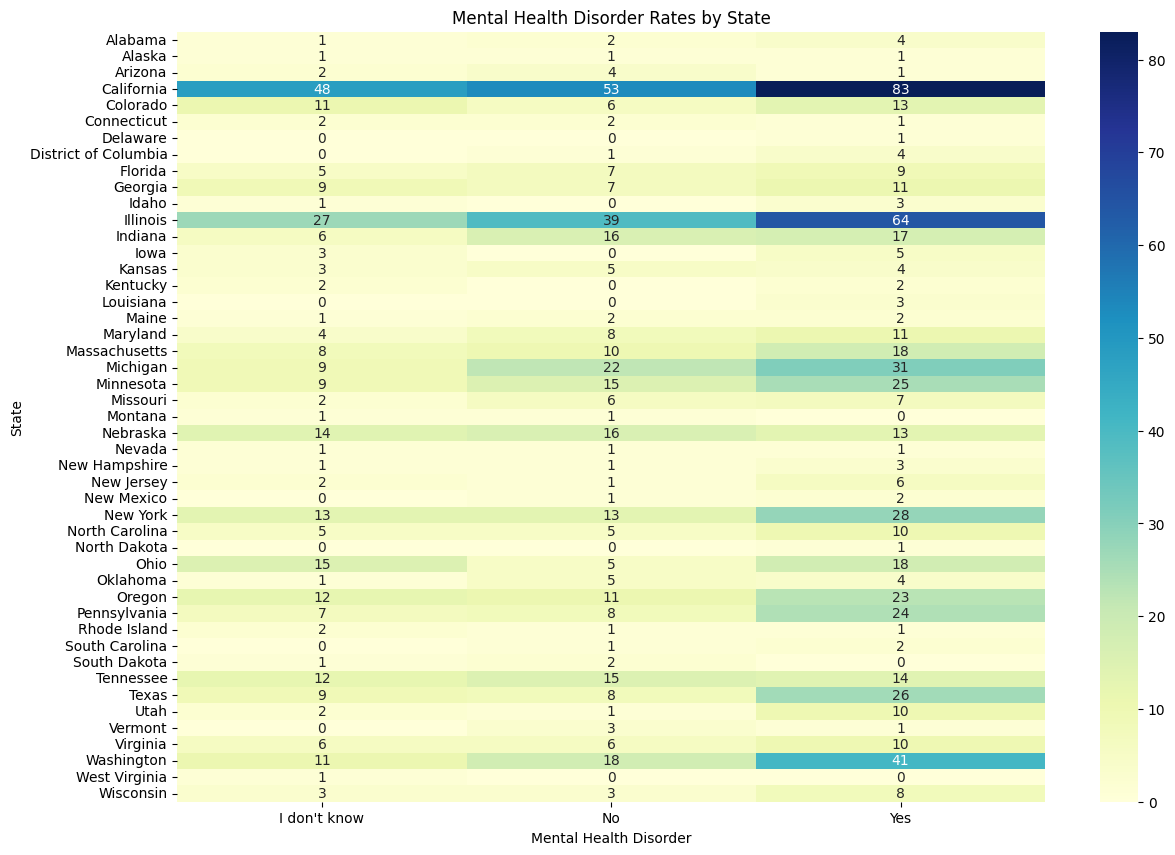

In [96]:
contingency_table = pd.crosstab(df_filtered['us_state'], df_filtered['mental_health_disorder'])

plt.figure(figsize=(14, 10))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Mental Health Disorder Rates by State')
plt.xlabel('Mental Health Disorder')
plt.ylabel('State')
plt.show()

<small>

##### **Explanation** 

- California & Illinois lead in awareness with the highest "Yes" responses, likely due to strong mental health initiatives.
- Low awareness in states like Delaware, Montana, and North Dakota suggests a need for more mental health outreach.

Recommendation: Expand mental health education and resources in states with high uncertainty and low awareness.


<small>

##### Are some states more likely to offer employer mental health benefits?

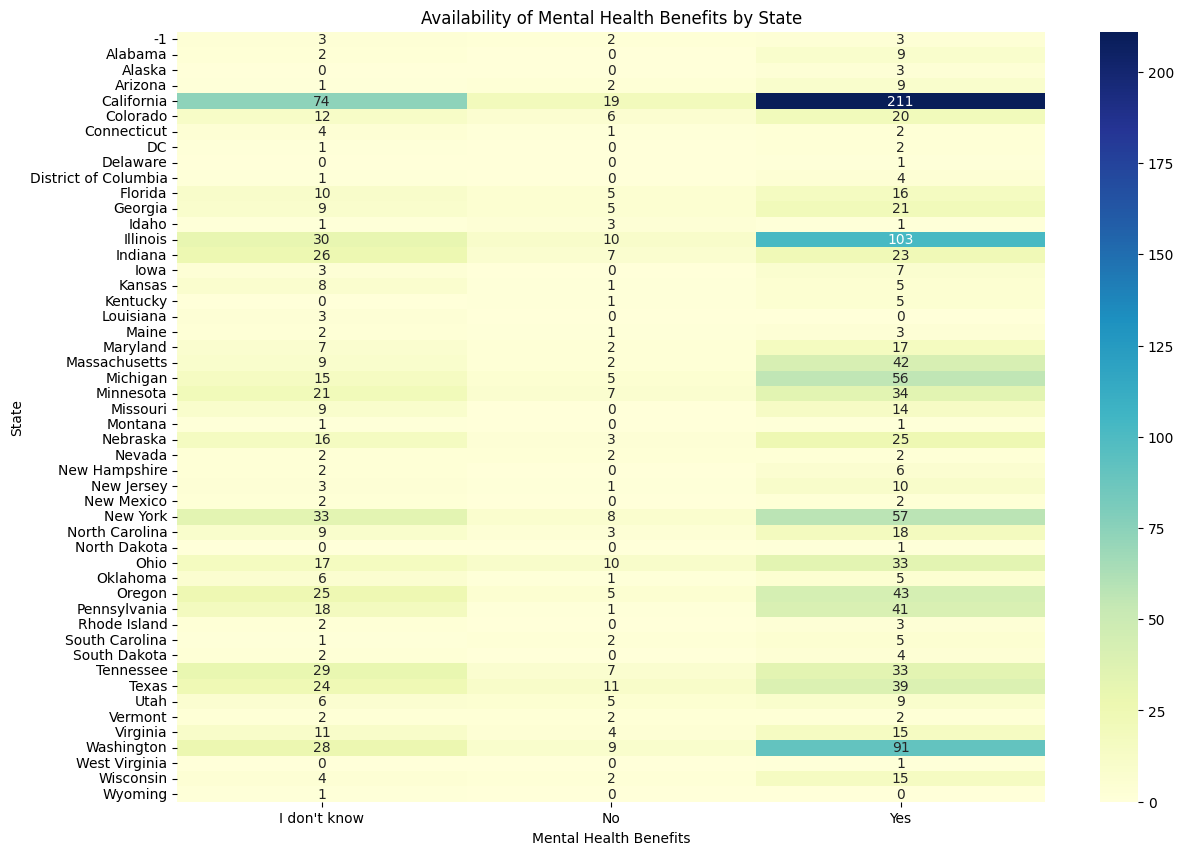

In [97]:

df_filtered['mental_health_benefits'] = df_filtered['mental_health_benefits'].replace(
    {"Don't know": "I don't know"}
)

contingency_table = pd.crosstab(df_filtered['us_state'], df_filtered['mental_health_benefits'])
plt.figure(figsize=(14, 10))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Availability of Mental Health Benefits by State')
plt.xlabel('Mental Health Benefits')
plt.ylabel('State')
plt.show()

<small>

##### **Explanation**
- The availability of mental health benefits varies significantly by state, with some states showing stronger support. California and Illinois, have a higher number of employers offering mental health benefits ("Yes") compared to others.

Recommendation: Increasing awareness about available benefits could be beneficial, given the high "I don't know" responses. 


<small>

##### Is there a correlation between company size and the availability of mental health benefits?

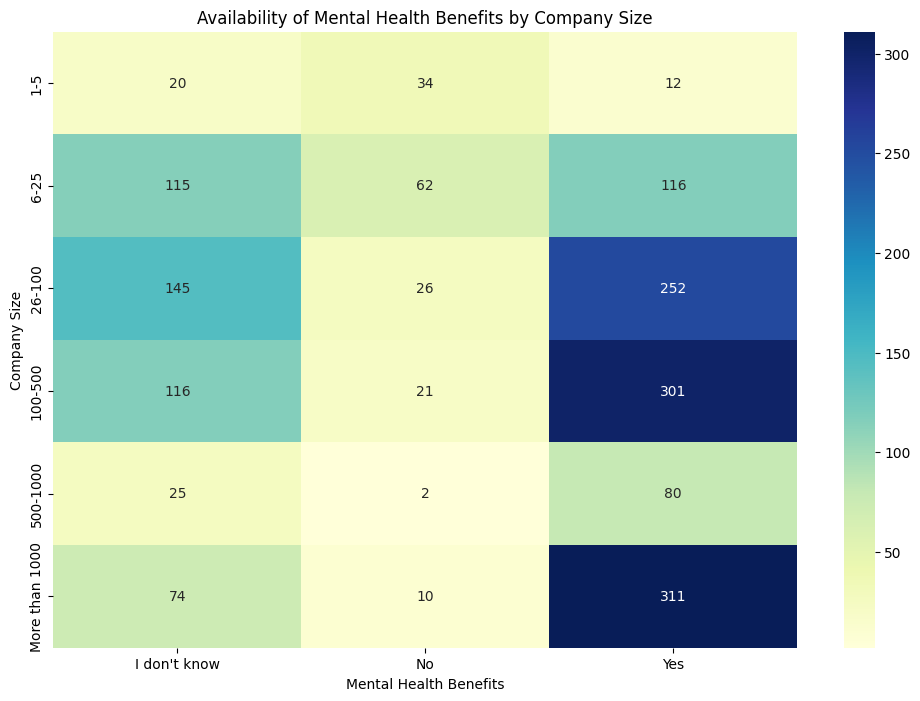

In [98]:
contingency_table = pd.crosstab(df_filtered['company_size'], df_filtered['mental_health_benefits'])

plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Availability of Mental Health Benefits by Company Size')
plt.xlabel('Mental Health Benefits')
plt.ylabel('Company Size')
plt.show()

<small>

##### **Explanation**

- Mid to large companies (e.g., 26-100, 100-500, 500-1000, and more than 1000 employees) are more likely to offer mental health benefits ("Yes").
- Smaller companies (e.g., 1-5 employees) have fewer instances of offering benefits.
- There is a notable number of "I don't know" responses across all company sizes, indicating some uncertainty or lack of awareness about the availability of benefits.

Recommendation: spread more awareness of mental health benefits. 


<small>

##### How does the perception of employer mental health priorities vary with company size?

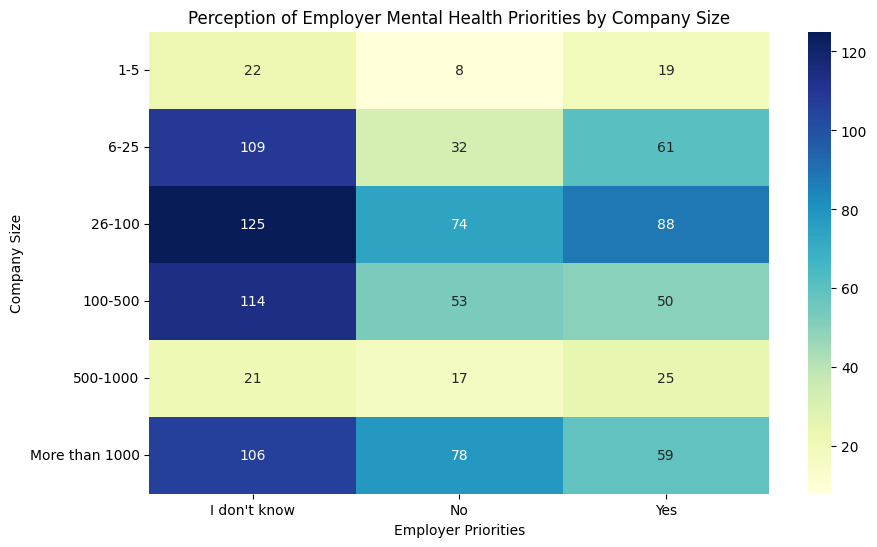

In [109]:
df_filtered['employer_priorities'] = df_filtered['employer_priorities'].replace(
    {"Don't know": "I don't know"}
)

contingency_table = pd.crosstab(df_filtered['company_size'], df_filtered['employer_priorities'])

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Perception of Employer Mental Health Priorities by Company Size')
plt.xlabel('Employer Priorities')
plt.ylabel('Company Size')
plt.show()


<small>

##### **Explanation**
- A significant number of employees across all company sizes are unsure about their employer's mental health priorities ("I don't know").

Recommendation: Increasing awareness and communication about mental health priorities

<small>

##### How do age, mental health benefits, and employer priorities relate to the reporting of mental health disorders?

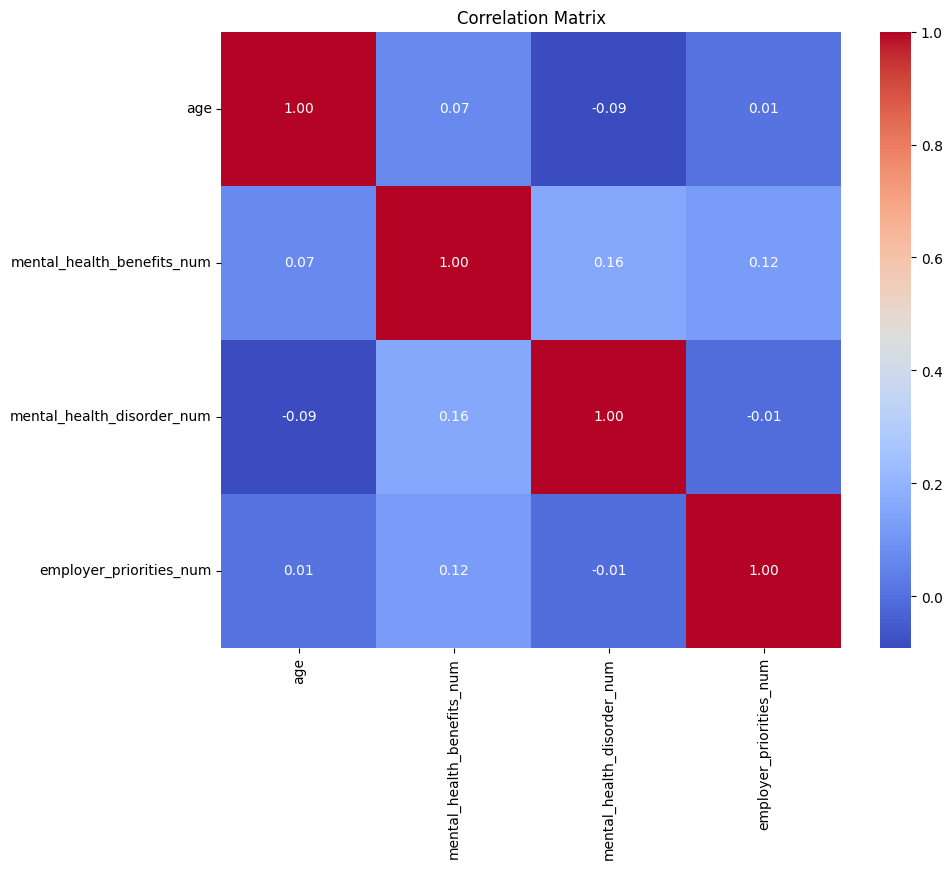

In [108]:
employer_priorities_mapping = {'I don\'t know': 0, 'No': 1, 'Yes': 2}

df_filtered['employer_priorities_num'] = df_filtered['employer_priorities'].map(employer_priorities_mapping)

numeric_df = df_filtered[['age', 'mental_health_benefits_num', 'mental_health_disorder_num', 'employer_priorities_num']]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

<small>

##### **Explanation** 

- Age and Mental Health Disorders: Slight negative correlation (-0.09) suggests age has little to no effect on the reporting of mental health disorders.
- Mental Health Benefits and Disorders: Weak positive correlation (0.16) indicates a slight tendency for those with mental health benefits to report disorders, but the relationship is not strong.
- Employer Priorities and Disorders: Very low correlation (-0.01) suggests that perceptions of employer priorities have minimal impact on the reporting of mental health disorders.

Overall, the correlations are weak, indicating that these factors have limited linear relationships with the reporting of mental health disorders.


<small>

### CONCLUSION

<small>

##### **Conclusion: Key Recommendations for Employers in the US Tech Industry**

1. Improve communication and awareness of mental health benefits. 
- Company Size Focus: the focus here is on large companies. Large companies (100+ employees) show high "I don’t know" responses, indicating potential communication gaps. Small companies (1-5 employees) have low responses across all categories, implying a lack of formal mental health policies in the first place. 
- State Focus: states with lower reported benefits should be targeted for improvement initiatives.
2. Foster an inclusive workplace by normalising mental health discussions and ensuring that disclosure does not impact hiring or career progression. 
- Age and Gender Focus: Employees aged 25-34 report the highest number of mental health disorders, followed by the 35-44 age group. Males report the highest count, followed by females, with minimal representation in the “Other” category. Employers should focus on reducing stigma among younger employees while ensuring older employees have adequate support. 
3. Improve anonymity in mental health support
- 1,147 employees indicated they do not know whether their anonymity is protected when accessing mental health resources.  
4. Employers must not only implement mental health policies but also train managers and HR teams to ensure those policies are effectively practiced.
- Employees who believe their employer prioritises mental health are less likely to experience an unsupportive response.
  
<small>

### IMPROVEMENTS

<small>

1. Incorporate additional datasets for comparison to strengthen findings.
2. This study focuses on employees in the tech industry; analysing data across different industries would provide a broader perspective.
3. Tracking mental health trends over time could help identify patterns and measure the effectiveness of workplace interventions.
4. Future research should explore deeper factors such as job satisfaction, workload, and leadership impact on mental health outcomes. 

<small>